# 🧹 Notebook 02 — Preprocessing & Feature Engineering
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Impute missing values using cubic spline interpolation
2. Aggregate 20 raw features → 4 physically meaningful covariates (T, P, H, V)
3. Create time-lagged covariates (P(t-1), P(t-2), P(t-3), T(t-1))
4. Add seasonal basis functions (sin/cos with period 52 weeks)
5. Check multicollinearity among aggregated covariates
6. Save cleaned, preprocessed DataFrames for both cities
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.interpolate import CubicSpline
from src.data_utils import (
    load_raw_data, split_by_city, missing_summary,
    NDVI_COLS, TEMP_COLS, PRECIP_COLS, HUMIDITY_COLS, ENV_FEATURE_COLS
)
from src.plot_utils import set_project_style, PALETTE, city_label, city_color, save_fig

set_project_style()
print('✅ All imports ready')

✅ All imports ready


## 1 · Load Raw Data

In [2]:
df = load_raw_data()
df_sj, df_iq = split_by_city(df)

print(f'San Juan : {len(df_sj)} weeks | Missing values: {df_sj[ENV_FEATURE_COLS].isnull().sum().sum()}')
print(f'Iquitos  : {len(df_iq)} weeks | Missing values: {df_iq[ENV_FEATURE_COLS].isnull().sum().sum()}')

San Juan : 936 weeks | Missing values: 380
Iquitos  : 520 weeks | Missing values: 168


## 2 · Missing Value Imputation (Cubic Spline)

Per the blueprint (Stage 1), we use **cubic spline interpolation** for gap-filling.
This preserves the smooth temporal structure better than linear interpolation.

In [3]:
def impute_cubic_spline(series):
    """Impute NaN values in a pandas Series using cubic spline interpolation."""
    s = series.copy()
    if s.isnull().sum() == 0:
        return s

    valid = s.dropna()
    if len(valid) < 4:  # Need at least 4 points for cubic spline
        return s.interpolate(method='linear')

    cs = CubicSpline(valid.index.values, valid.values, extrapolate=True)
    missing_idx = s[s.isnull()].index
    s.loc[missing_idx] = cs(missing_idx.values)
    return s


def impute_dataframe(df, cols):
    """Apply cubic spline imputation to specified columns of a DataFrame."""
    df_clean = df.copy()
    imputed_counts = {}
    for col in cols:
        n_missing = df_clean[col].isnull().sum()
        if n_missing > 0:
            df_clean[col] = impute_cubic_spline(df_clean[col])
            imputed_counts[col] = n_missing
    return df_clean, imputed_counts


# Apply to both cities
env_cols = [c for c in ENV_FEATURE_COLS if c in df_sj.columns]

df_sj_clean, sj_counts = impute_dataframe(df_sj, env_cols)
df_iq_clean, iq_counts = impute_dataframe(df_iq, env_cols)

print('=== San Juan — Imputed Columns ===')
for col, n in sj_counts.items():
    print(f'  {col}: {n} values imputed')

print(f'\n=== Iquitos — Imputed Columns ===')
for col, n in iq_counts.items():
    print(f'  {col}: {n} values imputed')

# Verify no NaNs remain
print(f'\n✅ San Juan remaining NaNs: {df_sj_clean[env_cols].isnull().sum().sum()}')
print(f'✅ Iquitos remaining NaNs: {df_iq_clean[env_cols].isnull().sum().sum()}')

=== San Juan — Imputed Columns ===
  ndvi_ne: 191 values imputed
  ndvi_nw: 49 values imputed
  ndvi_se: 19 values imputed
  ndvi_sw: 19 values imputed
  station_avg_temp_c: 6 values imputed
  reanalysis_avg_temp_k: 6 values imputed
  reanalysis_air_temp_k: 6 values imputed
  reanalysis_max_air_temp_k: 6 values imputed
  reanalysis_min_air_temp_k: 6 values imputed
  reanalysis_tdtr_k: 6 values imputed
  station_max_temp_c: 6 values imputed
  station_min_temp_c: 6 values imputed
  station_diur_temp_rng_c: 6 values imputed
  precipitation_amt_mm: 9 values imputed
  station_precip_mm: 6 values imputed
  reanalysis_precip_amt_kg_per_m2: 6 values imputed
  reanalysis_sat_precip_amt_mm: 9 values imputed
  reanalysis_relative_humidity_percent: 6 values imputed
  reanalysis_specific_humidity_g_per_kg: 6 values imputed
  reanalysis_dew_point_temp_k: 6 values imputed

=== Iquitos — Imputed Columns ===
  ndvi_ne: 3 values imputed
  ndvi_nw: 3 values imputed
  ndvi_se: 3 values imputed
  ndvi_sw: 

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\02_imputation_example.png


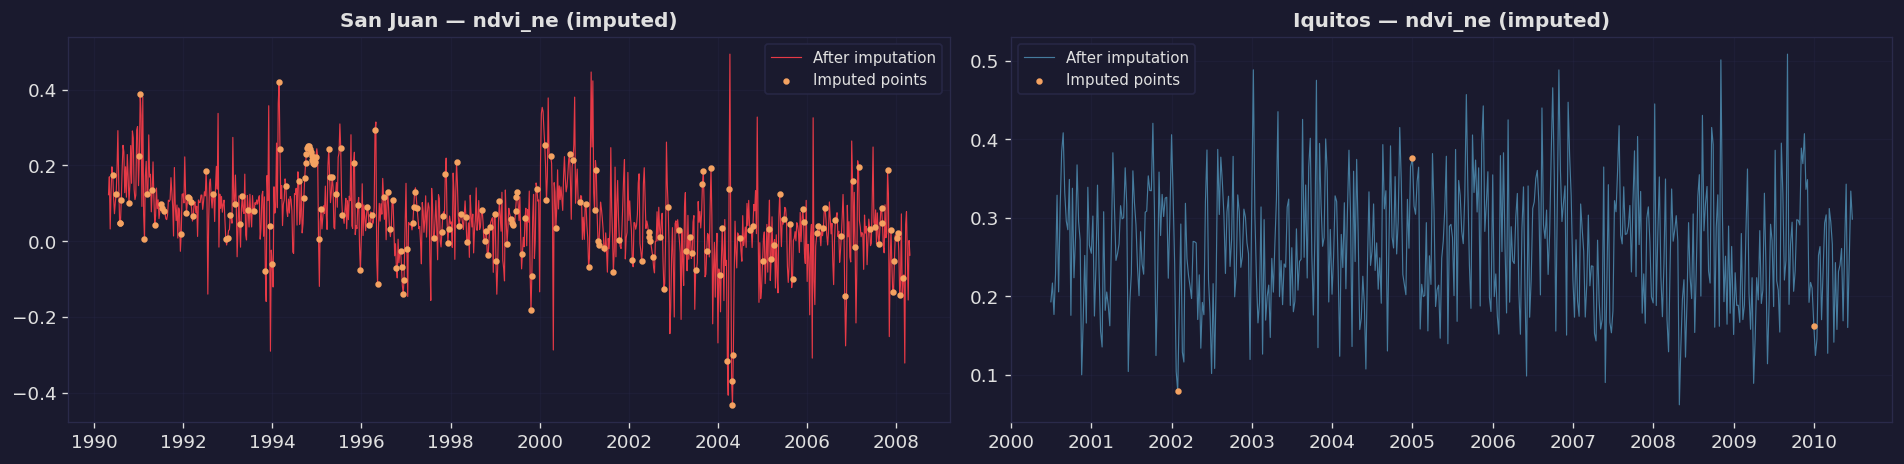

In [4]:
# Visualise imputation for a feature with many NaNs
feat = 'ndvi_ne'  # Typically has most missing values

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (raw, clean, code) in zip(axes, [(df_sj, df_sj_clean, 'sj'), (df_iq, df_iq_clean, 'iq')]):
    mask = raw[feat].isnull()
    ax.plot(clean['week_start_date'], clean[feat],
            color=city_color(code), linewidth=0.7, label='After imputation')
    if mask.any():
        ax.scatter(clean.loc[mask, 'week_start_date'], clean.loc[mask, feat],
                   color=PALETTE['accent'], s=8, zorder=5, label='Imputed points')
    ax.set_title(f'{city_label(code)} — {feat} (imputed)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '02_imputation_example')
plt.show()

## 3 · Feature Aggregation: 20 Features → 4 Covariates

Per the blueprint (Stage 2, Table):

| Symbol | Description | Source Features |
|---|---|---|
| **T(t)** | Mean temperature (°C) | `station_avg_temp_c`, `reanalysis_avg_temp_k` (converted to °C) |
| **P(t)** | Total precipitation (mm) | `precipitation_amt_mm`, `station_precip_mm` |
| **H(t)** | Relative humidity (%) | `reanalysis_relative_humidity_percent`, `reanalysis_dew_point_temp_k` (converted) |
| **V(t)** | Mean NDVI | Mean of `ndvi_ne`, `ndvi_nw`, `ndvi_se`, `ndvi_sw` |

In [5]:
def aggregate_covariates(df):
    """
    Aggregate 20 raw features into 4 physically meaningful covariates.
    H(t) now blends reanalysis_relative_humidity_percent with a Magnus-formula
    RH estimate derived from reanalysis_dew_point_temp_k, per blueprint spec.
    """
    import numpy as np
    out = df.copy()

    # T(t): Mean temperature in Celsius
    # reanalysis_avg_temp_k is in Kelvin -> convert first
    temp_c_from_k = df['reanalysis_avg_temp_k'] - 273.15
    out['T'] = (df['station_avg_temp_c'] + temp_c_from_k) / 2.0

    # P(t): Mean precipitation (mm)
    out['P'] = (df['precipitation_amt_mm'] + df['station_precip_mm']) / 2.0

    # H(t): Blueprint specifies blending relative_humidity_percent AND dew_point_temp_k.
    # Magnus formula converts dew point to an equivalent RH:
    #   RH = 100 * exp(17.625*Td/(243.04+Td)) / exp(17.625*T/(243.04+T))
    # where Td = dew-point temperature (Celsius), T = air temperature (Celsius).
    Td = df['reanalysis_dew_point_temp_k'] - 273.15   # dew point in Celsius
    T_c = temp_c_from_k.copy()                         # air temp in Celsius
    RH_magnus = (
        100.0
        * np.exp(17.625 * Td  / (243.04 + Td))
        / np.exp(17.625 * T_c / (243.04 + T_c))
    )
    RH_magnus = RH_magnus.clip(0, 100)   # enforce physical bounds
    out['H'] = (df['reanalysis_relative_humidity_percent'] + RH_magnus) / 2.0

    # V(t): Mean NDVI across all 4 quadrants
    out['V'] = df[NDVI_COLS].mean(axis=1)

    return out


df_sj_agg = aggregate_covariates(df_sj_clean)
df_iq_agg = aggregate_covariates(df_iq_clean)

# Quick summary
for code, dfc in [('sj', df_sj_agg), ('iq', df_iq_agg)]:
    print(f'\n=== {city_label(code)} -- Aggregated Covariates ===')
    print(dfc[['T', 'P', 'H', 'V']].describe().round(3).to_string())



=== San Juan -- Aggregated Covariates ===
             T        P        H        V
count  936.000  936.000  936.000  936.000
mean    26.560   31.102   78.244    0.112
std      1.277   32.940    3.427    0.067
min     23.029   -9.792   66.344   -0.263
25%     25.465    7.790   75.880    0.076
50%     26.741   21.795   78.377    0.111
75%     27.657   43.619   80.626    0.147
max     29.129  274.725   87.325    0.342

=== Iquitos -- Aggregated Covariates ===
             T        P        H        V
count  520.000  520.000  520.000  520.000
mean    26.741   63.003   84.744    0.255
std      1.005   41.478    7.899    0.073
min     23.132   -0.075   54.136    0.084
25%     26.096   35.010   79.673    0.201
50%     26.759   56.882   86.720    0.253
75%     27.411   81.984   91.094    0.306
max     29.245  295.045   97.044    0.504


  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\02_aggregated_covariates_sj.png


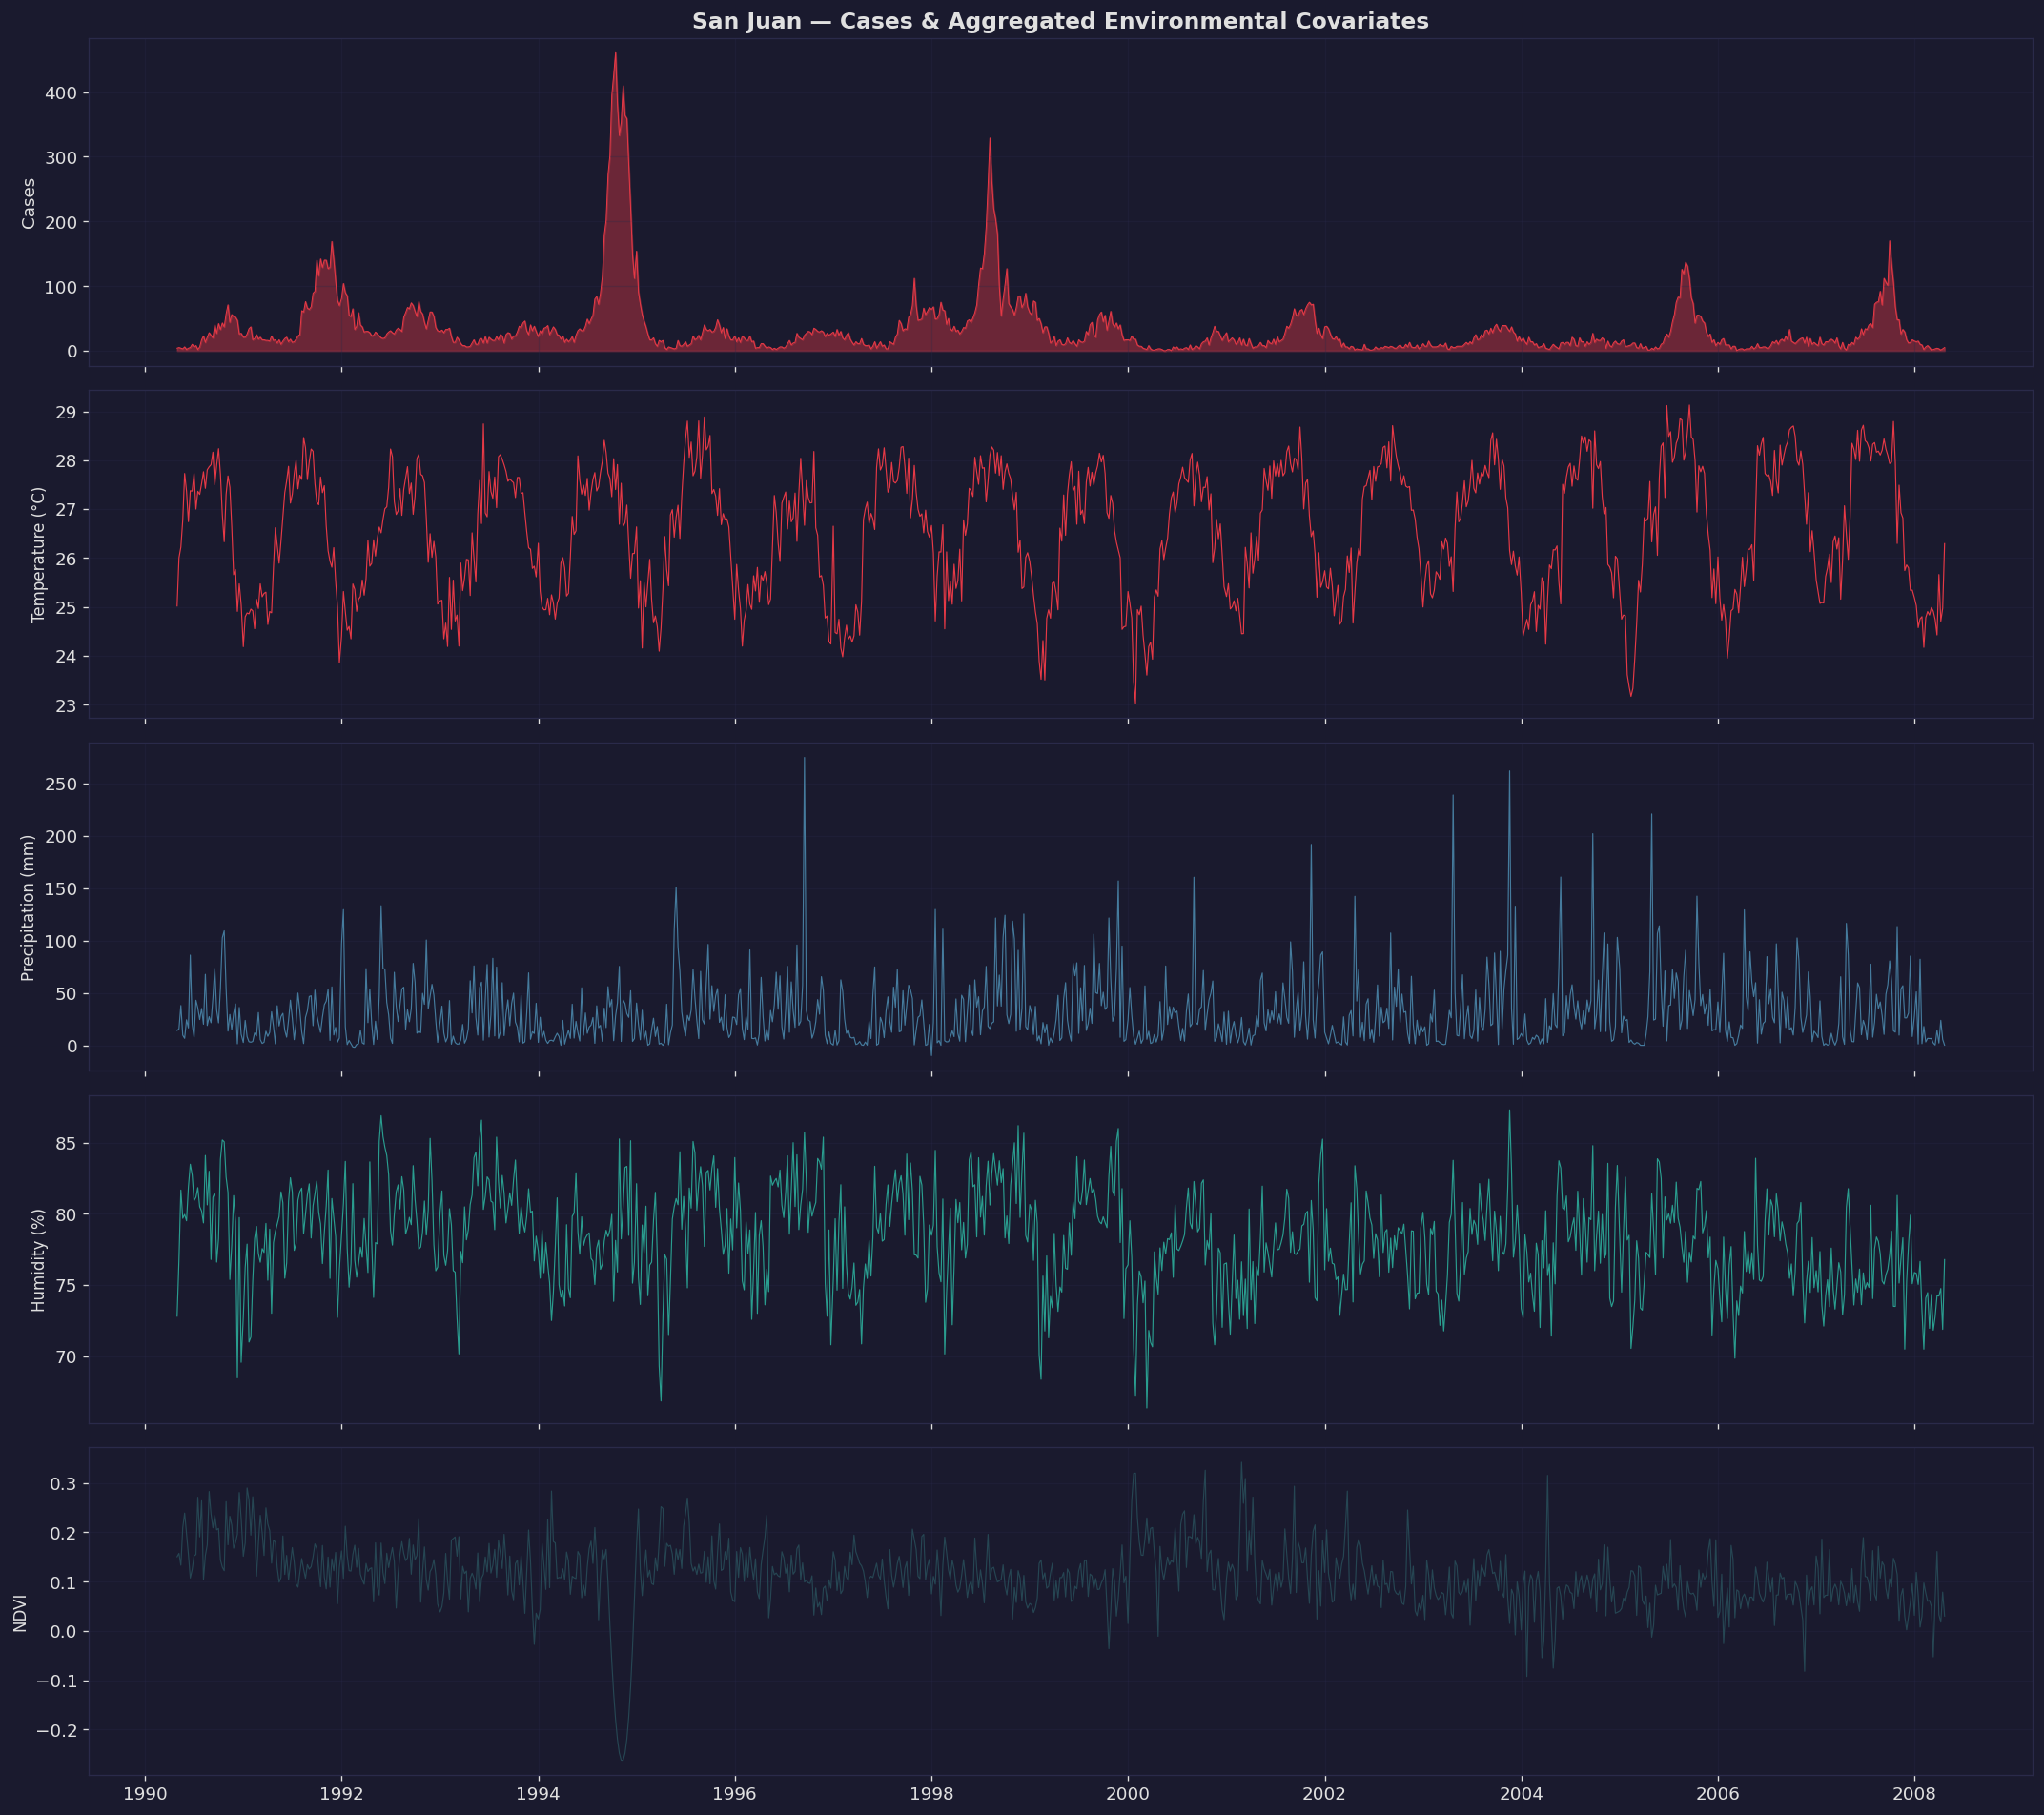

In [6]:
# Plot the 4 aggregated covariates alongside cases
fig, axes = plt.subplots(5, 1, figsize=(18, 16), sharex=True)
covariates = ['T', 'P', 'H', 'V']
cov_labels = ['Temperature (°C)', 'Precipitation (mm)', 'Humidity (%)', 'NDVI']
cov_colors = ['#E63946', '#457B9D', '#2A9D8F', '#264653']

# Cases on top
ax = axes[0]
ax.fill_between(df_sj_agg['week_start_date'], df_sj_agg['total_cases'],
                alpha=0.4, color=PALETTE['sj'])
ax.plot(df_sj_agg['week_start_date'], df_sj_agg['total_cases'],
        color=PALETTE['sj'], linewidth=0.6)
ax.set_ylabel('Cases')
ax.set_title('San Juan — Cases & Aggregated Environmental Covariates', fontsize=14)
ax.grid(True, alpha=0.3)

for i, (cov, label, color) in enumerate(zip(covariates, cov_labels, cov_colors)):
    ax = axes[i + 1]
    ax.plot(df_sj_agg['week_start_date'], df_sj_agg[cov],
            color=color, linewidth=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
save_fig(fig, '02_aggregated_covariates_sj')
plt.show()

## 4 · Lagged Covariates

Per the blueprint: rainfall today creates breeding sites → mosquitoes emerge 2-3 weeks later.
We create lagged terms: **P(t-1), P(t-2), P(t-3), T(t-1)**

In [7]:
def add_lagged_covariates(df):
    """Add time-lagged environmental covariates."""
    out = df.copy()

    # Precipitation lags (mosquito breeding cycle: 2-3 weeks)
    out['P_lag1'] = out['P'].shift(1)
    out['P_lag2'] = out['P'].shift(2)
    out['P_lag3'] = out['P'].shift(3)

    # Temperature lag (1 week)
    out['T_lag1'] = out['T'].shift(1)

    # Drop rows with NaN from shifting (first 3 rows)
    out = out.iloc[3:].reset_index(drop=True)

    return out


df_sj_lag = add_lagged_covariates(df_sj_agg)
df_iq_lag = add_lagged_covariates(df_iq_agg)

print(f'San Juan: {len(df_sj_lag)} weeks (dropped 3 for lags)')
print(f'Iquitos : {len(df_iq_lag)} weeks (dropped 3 for lags)')
print(f'\nLag columns: {[c for c in df_sj_lag.columns if "lag" in c]}')
print(f'\nNaN check (lag cols): {df_sj_lag[["P_lag1","P_lag2","P_lag3","T_lag1"]].isnull().sum().sum()}')

San Juan: 933 weeks (dropped 3 for lags)
Iquitos : 517 weeks (dropped 3 for lags)

Lag columns: ['P_lag1', 'P_lag2', 'P_lag3', 'T_lag1']

NaN check (lag cols): 0


## 5 · Seasonal Basis Functions

Add `sin(2πt/52)` and `cos(2πt/52)` to prevent SINDy from misattributing annual cycles to environmental covariates.

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\02_seasonal_basis.png


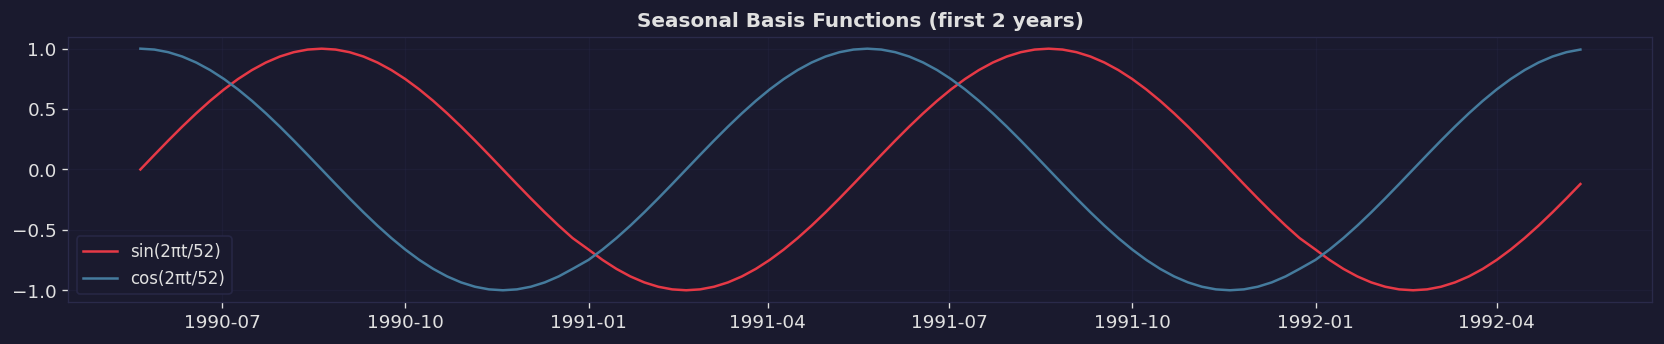

In [8]:
def add_seasonal_basis(df):
    """Add sin/cos seasonal basis functions with period = 52 weeks."""
    out = df.copy()
    t = np.arange(len(out))
    out['sin_season'] = np.sin(2 * np.pi * t / 52)
    out['cos_season'] = np.cos(2 * np.pi * t / 52)
    return out


df_sj_final = add_seasonal_basis(df_sj_lag)
df_iq_final = add_seasonal_basis(df_iq_lag)

# Quick plot of seasonal basis
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_sj_final['week_start_date'][:104], df_sj_final['sin_season'][:104],
        label='sin(2πt/52)', color=PALETTE['sj'])
ax.plot(df_sj_final['week_start_date'][:104], df_sj_final['cos_season'][:104],
        label='cos(2πt/52)', color=PALETTE['iq'])
ax.set_title('Seasonal Basis Functions (first 2 years)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, '02_seasonal_basis')
plt.show()

## 6 · Multicollinearity Check Among Aggregated Covariates

After aggregation from 20 → 4, the severe multicollinearity seen in the EDA should be resolved.

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\02_covariate_correlation.png


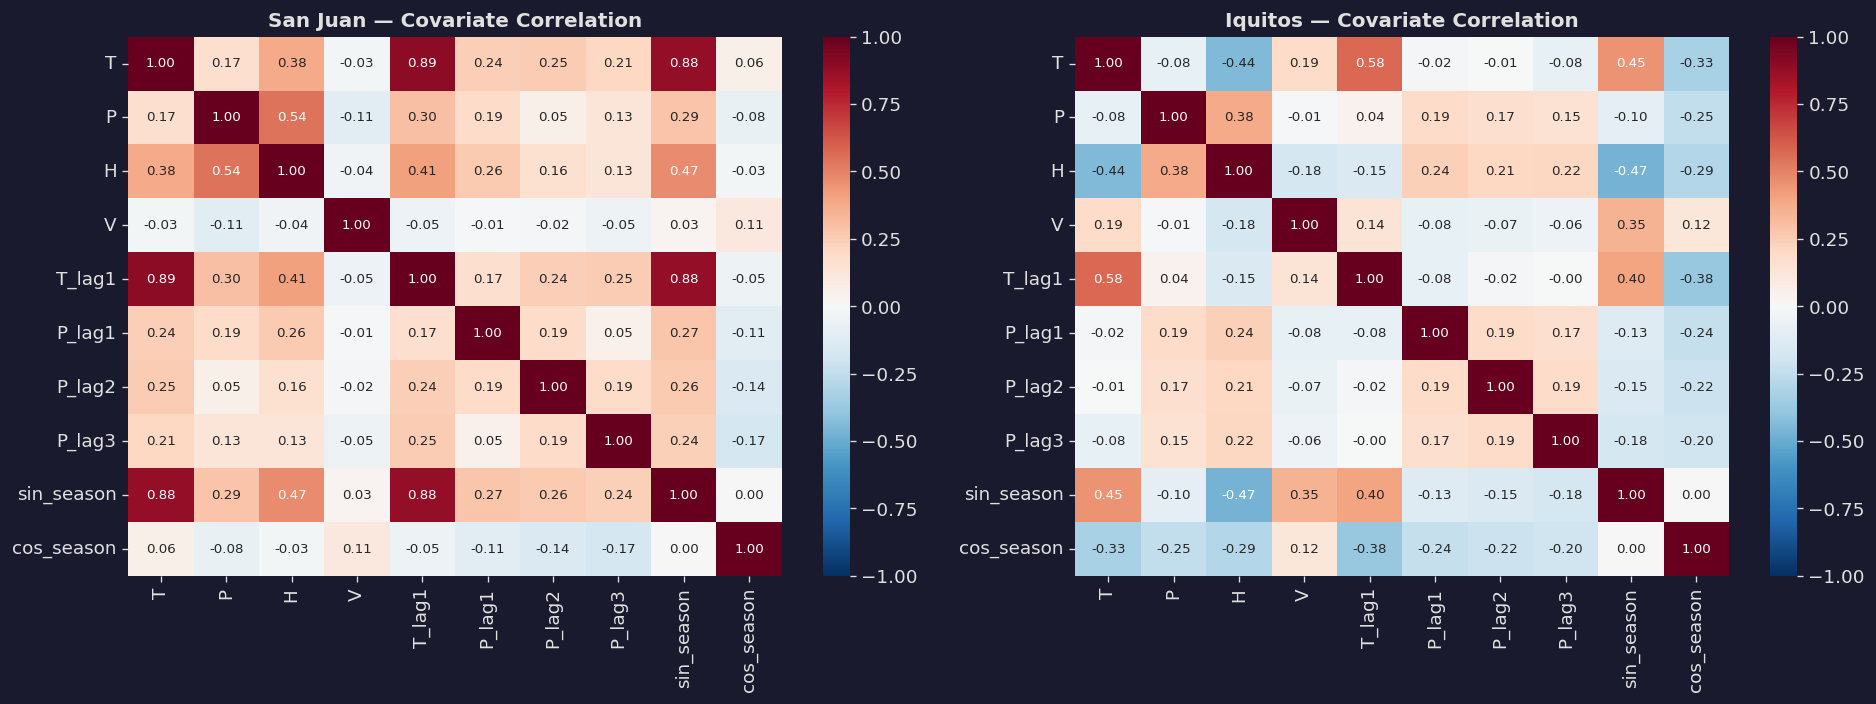


=== High correlations (|r| > 0.8) among aggregated covariates ===
  SJ: T ↔ T_lag1 = 0.892
  SJ: T ↔ sin_season = 0.881
  SJ: T_lag1 ↔ sin_season = 0.882
  IQ: None found ✅


In [9]:
# Correlation among the 4 aggregated + lagged covariates
cov_cols = ['T', 'P', 'H', 'V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3',
            'sin_season', 'cos_season']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (dfc, code) in zip(axes, [(df_sj_final, 'sj'), (df_iq_final, 'iq')]):
    corr = dfc[cov_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'{city_label(code)} — Covariate Correlation', fontsize=12)

plt.tight_layout()
save_fig(fig, '02_covariate_correlation')
plt.show()

# Flag any pairs with |r| > 0.8
print('\n=== High correlations (|r| > 0.8) among aggregated covariates ===')
for code, dfc in [('SJ', df_sj_final), ('IQ', df_iq_final)]:
    corr = dfc[cov_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high = [(i, c, upper.loc[i, c]) for c in upper.columns for i in upper.index
            if pd.notna(upper.loc[i, c]) and upper.loc[i, c] > 0.8]
    if high:
        for f1, f2, r in high:
            print(f'  {code}: {f1} ↔ {f2} = {r:.3f}')
    else:
        print(f'  {code}: None found ✅')

## 7 · Save Preprocessed Data

Save the cleaned, feature-engineered DataFrames for use in subsequent notebooks.

In [10]:
# Define the columns to carry forward
id_cols = ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases']
covariate_cols = ['T', 'P', 'H', 'V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3',
                  'sin_season', 'cos_season']

# Save
import os
os.makedirs('../data_processed', exist_ok=True)

df_sj_final[id_cols + covariate_cols].to_csv('../data_processed/sj_preprocessed.csv', index=False)
df_iq_final[id_cols + covariate_cols].to_csv('../data_processed/iq_preprocessed.csv', index=False)

print(f'✅ San Juan saved: {len(df_sj_final)} rows × {len(id_cols + covariate_cols)} cols')
print(f'✅ Iquitos  saved: {len(df_iq_final)} rows × {len(id_cols + covariate_cols)} cols')
print(f'\nColumns: {id_cols + covariate_cols}')

✅ San Juan saved: 933 rows × 15 cols
✅ Iquitos  saved: 517 rows × 15 cols

Columns: ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases', 'T', 'P', 'H', 'V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3', 'sin_season', 'cos_season']


In [11]:
# Final summary
print('=' * 60)
print('PREPROCESSING SUMMARY')
print('=' * 60)
print(f'\nSan Juan: {len(df_sj_final)} weeks (1990–2008)')
print(f'Iquitos : {len(df_iq_final)} weeks (2000–2010)')
print(f'\n4 Aggregated Covariates: T, P, H, V')
print(f'4 Lagged Covariates   : T_lag1, P_lag1, P_lag2, P_lag3')
print(f'2 Seasonal Basis      : sin_season, cos_season')
print(f'\nTotal covariate features: {len(covariate_cols)}')
print(f'Missing values: 0 (all imputed via cubic spline)')
print('=' * 60)

PREPROCESSING SUMMARY

San Juan: 933 weeks (1990–2008)
Iquitos : 517 weeks (2000–2010)

4 Aggregated Covariates: T, P, H, V
4 Lagged Covariates   : T_lag1, P_lag1, P_lag2, P_lag3
2 Seasonal Basis      : sin_season, cos_season

Total covariate features: 10
Missing values: 0 (all imputed via cubic spline)


## 📝 Summary

| Step | What We Did |
|---|---|
| **Imputation** | Cubic spline interpolation for all NaN values |
| **Aggregation** | 20 features → T (temp), P (precip), H (humidity), V (NDVI) |
| **Lags** | P(t-1), P(t-2), P(t-3), T(t-1) for delayed ecological effects |
| **Seasonality** | sin(2πt/52), cos(2πt/52) basis functions |
| **Multicollinearity** | Verified — aggregated covariates are weakly correlated |

